In [2]:
# Libraries for file managing
import shutil, os

#Libraries for import and manage databases and calculations
import pandas as pd
#import geopandas as gpd
import numpy as np
from scipy import interpolate

#Libraries for Visualization
# %matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

#Libraries for statistical modelling
from sklearn.model_selection import train_test_split
from statsmodels.stats.moment_helpers import cov2corr as cov2cor
import statsmodels.formula.api as smf
import warnings

In [5]:
# En Mixed_Effects_Eliasib.ipynb, reemplaza la carga así:
if 'Resids_Eliasib' not in dir():
    path_Resids_Eliasib = r'C:\Users\elias\OneDrive\Desktop\MachineLearning\ProyectoGrado\Resids_for_Eliasib.xlsx'
    Resids_Eliasib = pd.read_excel(path_Resids_Eliasib, index_col=0)

evid_Cols = list(Resids_Eliasib.columns[2:7])
event_table = Resids_Eliasib.groupby(by = ['EQID_Code']).mean(numeric_only=True)[evid_Cols]
event_table['EQID'] = event_table['EQID'].astype(int)

sta_Cols = ['SSN', 'Station Latitude (deg positive N)', 'Station Longitude (deg positive E)', 'Tn', 'P*', 'Cat']
Station_table = Resids_Eliasib.groupby(by = ['Station Code']).mean(numeric_only=True)[sta_Cols]
Station_table['SSN'] = Station_table['SSN'].astype(int)
Station_table['Cat'] = Station_table['Cat'].astype(int)


In [3]:
Resids_Eliasib_per_Period = pd.pivot_table(
    Resids_Eliasib, 
    values="Total", 
    index=["EQID_Code", "Station Code"], columns=["Period"]
)

Period_List = Resids_Eliasib_per_Period.columns
Period_Cols = ['T_%0.3fs'%(float(el)) for el in Period_List]

Resids_Eliasib_per_Period.columns = Period_Cols
Resids_Eliasib_per_Period.index = Resids_Eliasib_per_Period.index.map('-'.join)

Resids_Eliasib_per_Period.insert(0, 'Station', [el.split('-')[1] for el in list(Resids_Eliasib_per_Period.index)])
Resids_Eliasib_per_Period.insert(0, 'EQID', [el.split('-')[0] for el in list(Resids_Eliasib_per_Period.index)])
Resids_Eliasib_per_Period.insert(0, 'gm_ID', [el.split('-')[0] for el in list(Resids_Eliasib_per_Period.index)])


Resids_Eliasib_per_Period



,gm_ID,EQID,Station,T_0.010s,T_0.020s,T_0.030s,T_0.050s,T_0.075s,T_0.100s,T_0.150s,...,T_0.750s,T_1.000s,T_1.500s,T_2.000s,T_3.000s,T_4.000s,T_5.000s,T_6.000s,T_7.500s,T_10.000s
CO_19940606204742-BOG,CO_19940606204742,CO_19940606204742,BOG,0.681300,0.627268,0.647196,0.572867,0.478855,0.399829,0.308171,...,0.563728,0.197283,0.753792,1.452027,NaN,NaN,NaN,NaN,NaN,NaN
CO_19940606204742-CPENS,CO_19940606204742,CO_19940606204742,CPENS,0.350836,0.336882,0.304112,0.306020,0.270720,0.277237,0.286508,...,0.300049,-0.192698,-0.214124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CO_19940606204742-CVHER,CO_19940606204742,CO_19940606204742,CVHER,0.647138,0.665254,0.597588,0.483397,0.560433,0.505668,0.728767,...,0.292772,-0.094353,-0.031085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CO_19940606204742-ROSC,CO_19940606204742,CO_19940606204742,ROSC,0.080238,0.029721,0.017469,-0.029690,-0.082891,-0.250008,-0.327517,...,0.248373,0.447589,0.855064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CO_19940913100134-CANSE,CO_19940913100134,CO_19940913100134,CANSE,-0.272901,-0.314199,-0.308715,-0.423803,-0.569938,-0.404121,-0.867247,...,1.050645,1.249074,1.138547,0.798312,0.727863,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CO_20191226034829-SPBC,CO_20191226034829,CO_20191226034829,SPBC,-0.403660,-0.456402,-0.487671,-0.500301,-0.183344,-0.151202,-0.230677,...,-0.273315,-0.264166,-0.205991,-0.401792,-0.347373,-0.301881,-0.442261,-0.360688,0.121213,0.686679
CO_20191226034829-URMC,CO_20191226034829,CO_20191226034829,URMC,0.042491,0.045075,0.058340,0.547785,0.520019,0.100233,0.151642,...,-0.437336,-0.238347,-0.502630,-0.590890,-0.634995,-0.635513,-0.403759,-0.256427,-0.122327,NaN
CO_20191226034829-VIL,CO_20191226034829,CO_20191226034829,VIL,-0.061413,-0.104847,-0.075319,-0.012325,0.108191,0.134899,0.474066,...,0.154455,-0.318060,-0.653235,-0.385685,-0.128555,0.113842,0.284932,0.341627,0.474154,NaN
CO_20191226034829-YOT,CO_20191226034829,CO_20191226034829,YOT,-0.158983,-0.201083,-0.219426,-0.196645,-0.092163,0.330279,0.480112,...,-0.164014,-0.087099,-0.160008,0.100193,-0.057141,-0.230523,-0.303473,-0.300391,-0.187902,-0.072908


# Preprocessing Matrix Results


In [4]:
# Configuration dBe Matrix
dBe_Matrix = event_table.copy()

#Getting Number of Records
dBe_Matrix_temp = Resids_Eliasib.groupby(by = 'EQID_Code').count()// len(Period_List)
dict_Nrecords_dBe_temp = dict(zip(dBe_Matrix_temp.index, dBe_Matrix_temp.EQID))
dBe_Matrix['N_Records'] = [dict_Nrecords_dBe_temp[el] for el in dBe_Matrix.index]
temp_DF = pd.DataFrame(data=np.zeros([dBe_Matrix.shape[0], len(Period_List)]), columns=Period_Cols, index = dBe_Matrix.index)
dBe_Matrix = pd.concat([dBe_Matrix, temp_DF],axis=1)

dBe_Matrix

,EQID,Epicenter Latitude (deg; positive N),Epicenter Longitude (deg; positive E),Hypocenter Depth (km),Magnitude,N_Records,T_0.010s,T_0.020s,T_0.030s,T_0.050s,...,T_0.750s,T_1.000s,T_1.500s,T_2.000s,T_3.000s,T_4.000s,T_5.000s,T_6.000s,T_7.500s,T_10.000s
EQID_Code,,,,,,,,,,,,,,,,,,,,,
CO_19940606204742,1,2.9100,-75.9780,12.0,6.7765,4,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CO_19940913100134,2,7.1050,-76.6650,14.0,6.0202,2,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CO_19950119150505,4,5.0460,-72.9390,17.0,6.4996,10,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CO_19950120135924,5,5.1660,-72.9400,54.1,5.1646,4,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CO_19950122104129,6,5.1140,-72.9540,21.7,5.6455,4,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CO_19961104172500,13,7.3640,-77.3800,14.0,6.2562,3,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CO_19990125181918,20,4.4450,-75.6590,17.0,6.1355,21,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CO_20000117122008,23,6.7210,-71.9980,43.3,5.5532,3,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CO_20040818070652,34,2.2210,-76.6230,22.9,5.0667,4,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Configuration dBe Matrix
ds2s_Matrix = Station_table.copy()

#Getting Number of Records
ds2s_Matrix_temp = Resids_Eliasib.groupby(by = 'Station Code').count()// len(Period_List)
dict_Nrecords_ds2s_temp = dict(zip(ds2s_Matrix_temp.index, ds2s_Matrix_temp.SSN))
ds2s_Matrix['N_Records'] = [dict_Nrecords_ds2s_temp[el] for el in ds2s_Matrix.index]
temp_DF = pd.DataFrame(data=np.zeros([ds2s_Matrix.shape[0], len(Period_List)]), columns=Period_Cols, index = ds2s_Matrix.index)
ds2s_Matrix = pd.concat([ds2s_Matrix, temp_DF],axis=1)

ds2s_Matrix

,SSN,Station Latitude (deg positive N),Station Longitude (deg positive E),Tn,P*,Cat,N_Records,T_0.010s,T_0.020s,T_0.030s,...,T_0.750s,T_1.000s,T_1.500s,T_2.000s,T_3.000s,T_4.000s,T_5.000s,T_6.000s,T_7.500s,T_10.000s
Station Code,,,,,,,,,,,,,,,,,,,,,
ARMEC,24,4.5561,-75.6604,0.50,5.469949,4,13,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BAR2,30,6.5918,-73.1838,0.44,4.043005,4,6,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BET,31,2.7225,-75.4179,0.44,1.569933,4,12,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BOG,32,4.6410,-74.0800,1.30,3.004650,5,22,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CANAP,33,4.5502,-74.5141,0.24,2.025425,3,5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
URMC,271,3.2472,-74.3787,0.24,2.214998,3,7,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VALLC,241,10.5086,-73.2581,0.02,1.994359,2,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VIL,242,4.1111,-73.6934,1.00,6.196065,5,18,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Runing Mixed Effects Model

In [6]:
vcf = {"EQID": "0 + C(EQID)", "Station": "0 + C(Station)"}
N_RanEff = 2  # EQID y Station ID

# Within_site_residuals
Within_site_residuals = Resids_Eliasib_per_Period.iloc[:,:3].copy()
Within_site_residuals = pd.concat([Within_site_residuals, temp_DF],axis=1)

# Computed Total Residuals
Computed_TotRes = Resids_Eliasib_per_Period.iloc[:,:3].copy()
Computed_TotRes = pd.concat([Computed_TotRes, temp_DF],axis=1)

# Generating ResultsDecomp Matrix #
ResultsDecomp = pd.DataFrame(data = np.zeros([9,len(Period_Cols)]), columns=Period_Cols)
ResultsDecomp.index = ['Period','bias', 'tau', 'phi_s2s', 'phi_SS', 'phi', 'sigma', 'sigma_SS', 'sigma_Red_%']
ResultsDecomp.loc['Period'] = Period_List
ResultsDecomp

,T_0.010s,T_0.020s,T_0.030s,T_0.050s,T_0.075s,T_0.100s,T_0.150s,T_0.200s,T_0.250s,T_0.300s,...,T_0.750s,T_1.000s,T_1.500s,T_2.000s,T_3.000s,T_4.000s,T_5.000s,T_6.000s,T_7.500s,T_10.000s
Period,0.01,0.02,0.03,0.05,0.075,0.1,0.15,0.2,0.25,0.3,...,0.75,1.0,1.5,2.0,3.0,4.0,5.0,6.0,7.5,10.0
bias,0.00,0.00,0.00,0.00,0.000,0.0,0.00,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
tau,0.00,0.00,0.00,0.00,0.000,0.0,0.00,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
phi_s2s,0.00,0.00,0.00,0.00,0.000,0.0,0.00,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
phi_SS,0.00,0.00,0.00,0.00,0.000,0.0,0.00,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
phi,0.00,0.00,0.00,0.00,0.000,0.0,0.00,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sigma,0.00,0.00,0.00,0.00,0.000,0.0,0.00,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sigma_SS,0.00,0.00,0.00,0.00,0.000,0.0,0.00,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sigma_Red_%,0.00,0.00,0.00,0.00,0.000,0.0,0.00,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
##################################
# %%
for i_IM in range(len(Period_Cols)):
    DReg = Resids_Eliasib_per_Period[['gm_ID', 'EQID', 'Station', Period_Cols[i_IM]]].copy()
    DReg.rename(columns={Period_Cols[i_IM]: Period_Cols[i_IM].replace('.', '_')}, inplace=True)
    DReg = DReg.replace([np.inf, -np.inf], np.nan)
    DReg = DReg.replace("", np.nan)
    DReg = DReg.dropna()
    DReg["groups"] = 1
    print('Regressions for %s' % (DReg.columns[-2]))

    Ec_modelo = '~ 1'
    FF = DReg.columns[-2] + Ec_modelo

    mixed = smf.mixedlm(FF, vc_formula=vcf, re_formula="0", data=DReg,
                            groups="groups")
    mixed_fit = mixed.fit()
    ## Filtering nan in Database - idea try test/train split to see the stability of the residuals
    # Getting overal results
    ResultsDecomp.loc['bias', Period_Cols[i_IM]] = mixed_fit.params['Intercept']
    ResultsDecomp.loc['tau', Period_Cols[i_IM]] = np.sqrt(mixed_fit.params['EQID Var']*mixed_fit.scale)
    ResultsDecomp.loc['phi_s2s', Period_Cols[i_IM]] = np.sqrt(mixed_fit.params['Station Var']*mixed_fit.scale) #the params dictionary contained the varcomps partitioned over the scale 
    ResultsDecomp.loc['phi_SS', Period_Cols[i_IM]] = np.sqrt(mixed_fit.scale) # The unexplained variance of the model
    ResultsDecomp.loc['phi', Period_Cols[i_IM]] = np.sqrt(ResultsDecomp.loc['phi_SS', Period_Cols[i_IM]]**2 +ResultsDecomp.loc['phi_s2s', Period_Cols[i_IM]]**2)
    ResultsDecomp.loc['sigma', Period_Cols[i_IM]] = np.sqrt(ResultsDecomp.loc['phi', Period_Cols[i_IM]]**2 +ResultsDecomp.loc['tau', Period_Cols[i_IM]]**2)
    ResultsDecomp.loc['sigma_SS', Period_Cols[i_IM]] = np.sqrt(ResultsDecomp.loc['phi_SS', Period_Cols[i_IM]]**2 +ResultsDecomp.loc['tau', Period_Cols[i_IM]]**2)
    ResultsDecomp.loc['sigma_Red_%', Period_Cols[i_IM]] = ResultsDecomp.loc['sigma_SS', Period_Cols[i_IM]]/ResultsDecomp.loc['sigma', Period_Cols[i_IM]]

    # Extracting Random Effects
    dRanEff = pd.DataFrame.from_dict(mixed_fit.random_effects)
    dRanEff.insert(0, 'Random Effect', [el.split('[', 1)[1].split('(', 1)[1].split(')', 1)[0] for el in dRanEff.index])
    dRanEff.insert(1, 'EQID', [el.split('[', 1)[1].split('(', 1)[1].split(')', 1)[1].split('[')[1].split(']')[0] for el in dRanEff.index])

    # Extracting Between Event Residual
    dBe_temp = dRanEff[dRanEff['Random Effect'] == 'EQID']
    dBe_temp.columns = ['Random Effect', 'EQID', 'dBe']
    dBe_temp = dBe_temp[['EQID', 'dBe']]
    dict_dBe_values = dict(zip(dBe_temp['EQID'], dBe_temp['dBe']))
    dBe_Matrix[Period_Cols[i_IM]] = dBe_Matrix.index.to_series().map(dict_dBe_values)

    # Extracting Between Station Residual
    dSt_temp = dRanEff[dRanEff['Random Effect'] == 'Station']
    dSt_temp.columns = ['Random Effect', 'Station', 'dSt']
    dSt_temp = dSt_temp[['Station', 'dSt']]
    dict_dSt_values = dict(zip(dSt_temp['Station'], dSt_temp['dSt']))
    ds2s_Matrix[Period_Cols[i_IM]] = ds2s_Matrix.index.to_series().map(dict_dSt_values)

    # Extracting Within Station Residual
    dict_WSR = dict(zip(DReg.gm_ID,mixed_fit.resid)) # Within Site Residuals
    Within_site_residuals[Period_Cols[i_IM]] = Within_site_residuals.gm_ID.apply(lambda x: dict_WSR.get(x))
    DReg['dSt'] = DReg['Station'].apply(lambda x: dict_dSt_values.get(x))
    DReg['dBe'] = DReg['EQID'].apply(lambda x: dict_dBe_values.get(x))
    DReg['bias'] = ResultsDecomp.loc['bias', Period_Cols[i_IM]]
    Computed_TotRes[Period_Cols[i_IM]] = Within_site_residuals[Period_Cols[i_IM]] + DReg['dBe'] + DReg['dSt'] + DReg['bias']



Regressions for T_0_010s
Regressions for T_0_020s
Regressions for T_0_030s
Regressions for T_0_050s
Regressions for T_0_075s
Regressions for T_0_100s
Regressions for T_0_150s
Regressions for T_0_200s
Regressions for T_0_250s
Regressions for T_0_300s
Regressions for T_0_400s
Regressions for T_0_500s
Regressions for T_0_750s
Regressions for T_1_000s
Regressions for T_1_500s
Regressions for T_2_000s
Regressions for T_3_000s
Regressions for T_4_000s
Regressions for T_5_000s
Regressions for T_6_000s
Regressions for T_7_500s
Regressions for T_10_000s


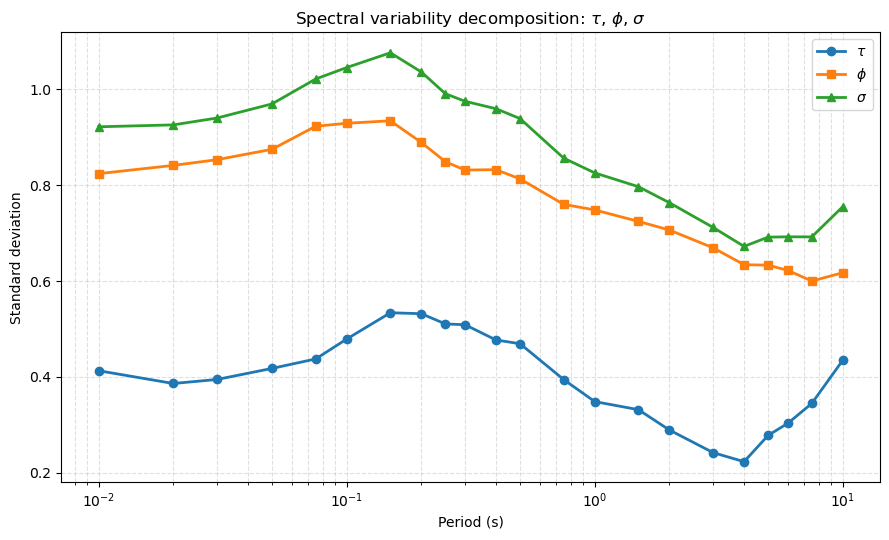

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Plot tau, phi y sigma
# =========================
periods = pd.to_numeric(ResultsDecomp.loc['Period'], errors='coerce').to_numpy(dtype=float)
tau     = pd.to_numeric(ResultsDecomp.loc['tau'], errors='coerce').to_numpy(dtype=float)
phi     = pd.to_numeric(ResultsDecomp.loc['phi'], errors='coerce').to_numpy(dtype=float)
sigma   = pd.to_numeric(ResultsDecomp.loc['sigma'], errors='coerce').to_numpy(dtype=float)

mask = np.isfinite(periods) & np.isfinite(tau) & np.isfinite(phi) & np.isfinite(sigma)

plt.figure(figsize=(9, 5.5))
plt.plot(periods[mask], tau[mask],   marker='o', lw=2, label=r'$\tau$')
plt.plot(periods[mask], phi[mask],   marker='s', lw=2, label=r'$\phi$')
plt.plot(periods[mask], sigma[mask], marker='^', lw=2, label=r'$\sigma$')

plt.xscale('log')
plt.xlabel('Period (s)')
plt.ylabel('Standard deviation')
plt.title(r'Spectral variability decomposition: $\tau$, $\phi$, $\sigma$')
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
ResultsDecomp

,T_0.010s,T_0.020s,T_0.030s,T_0.050s,T_0.075s,T_0.100s,T_0.150s,T_0.200s,T_0.250s,T_0.300s,...,T_0.750s,T_1.000s,T_1.500s,T_2.000s,T_3.000s,T_4.000s,T_5.000s,T_6.000s,T_7.500s,T_10.000s
Period,0.010000,0.020000,0.030000,0.050000,0.075000,1.000000e-01,0.150000,0.200000,0.250000,0.300000,...,7.500000e-01,1.000000,1.500000,2.000000,3.000000,4.000000,5.000000,6.000000,7.500000,10.000000
bias,0.000003,0.000003,0.000002,0.000004,0.000007,-5.946061e-07,-0.000002,0.000003,-0.000002,0.000003,...,2.183861e-07,-0.000005,-0.000001,-0.000006,0.000010,0.000002,-0.000004,-0.000002,0.000004,-0.000012
tau,0.412980,0.386330,0.394700,0.417772,0.437504,4.789480e-01,0.533839,0.531851,0.510554,0.508862,...,3.945062e-01,0.348594,0.331754,0.289331,0.242237,0.223318,0.278134,0.303193,0.344792,0.434896
phi_s2s,0.566030,0.576176,0.595414,0.628396,0.677535,6.939687e-01,0.708886,0.629696,0.578987,0.547505,...,4.720823e-01,0.476081,0.453145,0.427144,0.398381,0.353607,0.356291,0.341843,0.308682,0.268446
phi_SS,0.598600,0.612699,0.610699,0.608345,0.626353,6.173969e-01,0.608264,0.627296,0.620592,0.625610,...,5.953538e-01,0.577206,0.565051,0.562493,0.537722,0.526222,0.523296,0.519856,0.514553,0.555767
phi,0.823840,0.841058,0.852919,0.874623,0.922698,9.288550e-01,0.934080,0.888829,0.848740,0.831354,...,7.598077e-01,0.748211,0.724309,0.706293,0.669218,0.633994,0.633073,0.622179,0.600041,0.617204
sigma,0.921555,0.925543,0.939818,0.969278,1.021167,1.045066e+00,1.075866,1.035801,0.990467,0.974726,...,8.561209e-01,0.825432,0.796670,0.763258,0.711710,0.672175,0.691477,0.692122,0.692048,0.755033
sigma_SS,0.727238,0.724328,0.727146,0.737982,0.764021,7.813899e-01,0.809301,0.822415,0.803617,0.806430,...,7.141998e-01,0.674303,0.655243,0.632543,0.589766,0.571648,0.592619,0.601811,0.619392,0.705699
sigma_Red_%,0.789141,0.782598,0.773709,0.761373,0.748184,7.476944e-01,0.752232,0.793989,0.811351,0.827340,...,8.342277e-01,0.816909,0.822476,0.828741,0.828660,0.850445,0.857034,0.869516,0.895013,0.934660
